# TelecomX Parte 2- Predicción de Fuga de Clientes (Churn)
## Machine Learning y Modelado Predictivo
---

###  📌 Contexto del Proyecto

##### Este proyecto está asociado la segunda fase del análisis de evasión de clientes de Telecom X, enfocándose en la construcción de modelos predictivos de Machine Learning capaces de anticipar qué clientes tienen mayor probabilidad de cancelar sus servicios.
---

### 🎯 Objetivos

1.  **Preparar los datos** para modelado (codificación, normalización)
2.  **Analizar correlaciones** y seleccionar las variables más relevantes
3.  **Entrenar múltiples modelos** de clasificación (Random Forest, XGBoost, Regresión Logística)
4.  **Evaluar el rendimiento** con métricas robustas (Accuracy, Precision, Recall, F1, ROC-AUC)
5.  **Interpretar resultados** usando SHAP y feature importance
6.  **Generar conclusiones estratégicas** para la toma de decisiones de negocio
---

### 🛠️ Tecnologías y Librerías

- **Preprocesamiento:** Pandas, NumPy, Scikit-learn
- **Visualización:** Matplotlib, Seaborn, Plotly
- **Modelado:** Random Forest, XGBoost, Logistic Regression
- **Interpretabilidad:** SHAP (SHapley Additive exPlanations)
- **Evaluación:** Scikit-learn Metrics, Confusion Matrix, ROC-AUC
---

## Configuración del Entorno
---
### 1.- Importar Librerías


In [17]:
# IMPORTACIÓN DE LIBRERÍAS
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Modelos de Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Interpretabilidad
import shap

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías ok")

✅ Librerías ok


### 2.- Cargar Dataset Limpio

##### Se carga el dataset archivo: **telecomx_limpio.csv**
(Preprocesado en la Parte 1 del proyecto).


In [18]:
import pandas as pd

url = "https://raw.githubusercontent.com/paros/Challenge-Telecom-X-Parte2/main/telecomx_limpio.csv"
df = pd.read_csv(url)

# Vista general del dataset
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*40)
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df.head()



INFORMACIÓN GENERAL DEL DATASET
Dimensiones: 7,267 filas x 23 columnas

Memoria utilizada: 7.07 MB


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Tipo_Internet,Seguridad_Online,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Binaria
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,No,Sí,No,Sí,Sí,No,One year,Sí,Mailed check,65.6,593.30,2.19,0.0
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,No,No,No,No,No,Sí,Month-to-month,No,Mailed check,59.9,542.40,2.00,0.0
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,No,No,Sí,No,No,No,Month-to-month,Sí,Electronic check,73.9,280.85,2.46,1.0
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,No,Sí,Sí,No,Sí,Sí,Month-to-month,Sí,Electronic check,98.0,1237.85,3.27,1.0
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,No,No,No,Sí,Sí,No,Month-to-month,Sí,Mailed check,83.9,267.40,2.80,1.0


In [19]:
# dataset
print("ESTRUCTURA DE DATOS")
print("="*40)
df.info()

print("\n\n ESTADÍSTICAS DESCRIPTIVAS")
print("="*40)
df.describe()

ESTRUCTURA DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   object 
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Tiene_Pareja            7267 non-null   object 
 5   Tiene_Dependientes      7267 non-null   object 
 6   Meses_Contrato          7267 non-null   int64  
 7   Servicio_Telefono       7267 non-null   object 
 8   Multiples_Lineas        7267 non-null   object 
 9   Tipo_Internet           7267 non-null   object 
 10  Seguridad_Online        5686 non-null   object 
 11  Backup_Online           5686 non-null   object 
 12  Proteccion_Dispositivo  5686 non-null   object 
 13  Soporte_Tecnico         5686 non-null   object 
 14  Streaming_TV        

,Adulto_Mayor,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Binaria
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7043.000000
mean,0.162653,32.346498,64.720098,2277.182035,2.157292,0.265370
std,0.369074,24.571773,30.129572,2268.648587,1.004407,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.610000,0.000000
25%,0.000000,9.000000,35.425000,396.200000,1.180000,0.000000
50%,0.000000,29.000000,70.300000,1389.200000,2.340000,0.000000
75%,0.000000,55.000000,89.875000,3778.525000,2.995000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,3.960000,1.000000


In [20]:
df.columns

Index(['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefono',
       'Multiples_Lineas', 'Tipo_Internet', 'Seguridad_Online',
       'Backup_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
       'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato',
       'Factura_Digital', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales',
       'Cuentas_Diarias', 'Evasion_Binaria'],
      dtype='object')

---

## 3.- Preparación de Datos para Machine Learning


In [21]:
# Identificar tipos de variables
print("IDENTIFICACIÓN DE TIPOS DE VARIABLES")
print("="*40)

numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Remover la variable objetivo de las listas
if 'Evasion_Binaria' in numericas:
    numericas.remove('Evasion_Binaria')
if 'Evasion_Binaria' in categoricas:
    categoricas.remove('Evasion_Binaria')

print(f"\n Variables Numéricas ({len(numericas)}):")
for var in numericas:
    print(f"  • {var}")
print(f"\n Variables Categóricas ({len(categoricas)}):")
for var in categoricas:
    unique_count = df[var].nunique()
    print(f"  • {var} ({unique_count} categorías)")


IDENTIFICACIÓN DE TIPOS DE VARIABLES

 Variables Numéricas (5):
  • Adulto_Mayor
  • Meses_Contrato
  • Cargos_Mensuales
  • Cargos_Totales
  • Cuentas_Diarias

 Variables Categóricas (17):
  • ID_Cliente (7267 categorías)
  • Evasion (2 categorías)
  • Genero (2 categorías)
  • Tiene_Pareja (2 categorías)
  • Tiene_Dependientes (2 categorías)
  • Servicio_Telefono (2 categorías)
  • Multiples_Lineas (3 categorías)
  • Tipo_Internet (3 categorías)
  • Seguridad_Online (2 categorías)
  • Backup_Online (2 categorías)
  • Proteccion_Dispositivo (2 categorías)
  • Soporte_Tecnico (2 categorías)
  • Streaming_TV (2 categorías)
  • Streaming_Peliculas (2 categorías)
  • Tipo_Contrato (3 categorías)
  • Factura_Digital (2 categorías)
  • Metodo_Pago (4 categorías)


In [22]:
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df)) * 100

# Crear dataframe de nulos
nulos_df = pd.DataFrame({
    'Variable': nulos.index,
    'Nulos': nulos.values,
    'Porcentaje': nulos_pct.values
})

nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(nulos_df) > 0:
    print("\n Variables con valores nulos:")
    print(nulos_df.to_string(index=False))
    print("\n ⚠️ Eliminar")
else:
    print("\n✅ No se encontraron valores nulos en el dataset")



 Variables con valores nulos:
              Variable  Nulos  Porcentaje
      Seguridad_Online   1581   21.755883
         Backup_Online   1581   21.755883
Proteccion_Dispositivo   1581   21.755883
       Soporte_Tecnico   1581   21.755883
   Streaming_Peliculas   1581   21.755883
          Streaming_TV   1581   21.755883
               Evasion    224    3.082427
       Evasion_Binaria    224    3.082427

 ⚠️ Eliminar


### 4.- Codificación de Variables Categóricas


- **Label Encoding:** Para variables binarias (ej: Yes/No, Male/Female)
- **One-Hot Encoding:** Para variables con múltiples categorías sin orden



In [23]:
# Crea copia dataset original
df_encoded = df.copy()

print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*40)

# Codificar variable objetivo (Churn)
if df_encoded['Evasion_Binaria'].dtype == 'object':
    le_churn = LabelEncoder()
    df_encoded['Evasion_Binaria'] = le_churn.fit_transform(df_encoded['Evasion_Binaria'])
    print(f"\n🎯 Variable objetivo codificada:")
    print(f"   {dict(zip(le_churn.classes_, le_churn.transform(le_churn.classes_)))}")

# Identificar variables binarias (2 valores únicos)
variables_binarias = [col for col in categoricas if df[col].nunique() == 2]

# Label Encoding para variables binarias
if variables_binarias:
    print(f"\n Label Encoding aplicado a {len(variables_binarias)} variables binarias:")
    for col in variables_binarias:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"   • {col}: {mapping}")


# One-Hot Encoding para variables con múltiples categorías
variables_multiclase = [col for col in categoricas if df[col].nunique() > 2]

if variables_multiclase:
    print(f"\n One-Hot Encoding aplicado a {len(variables_multiclase)} variables:")
    df_encoded = pd.get_dummies(df_encoded, columns=variables_multiclase, drop_first=True)
    for col in variables_multiclase:
        nuevas_cols = [c for c in df_encoded.columns if c.startswith(col + '_')]
        print(f"   • {col} → {len(nuevas_cols)} nuevas columnas")

print(f"\n✅ Codificación completada")


CODIFICACIÓN DE VARIABLES CATEGÓRICAS

 Label Encoding aplicado a 12 variables binarias:
   • Evasion: {'No': np.int64(0), 'Sí': np.int64(1), nan: np.int64(2)}
   • Genero: {'Femenino': np.int64(0), 'Masculino': np.int64(1)}
   • Tiene_Pareja: {'No': np.int64(0), 'Sí': np.int64(1)}
   • Tiene_Dependientes: {'No': np.int64(0), 'Sí': np.int64(1)}
   • Servicio_Telefono: {'No': np.int64(0), 'Sí': np.int64(1)}
   • Seguridad_Online: {'No': np.int64(0), 'Sí': np.int64(1), nan: np.int64(2)}
   • Backup_Online: {'No': np.int64(0), 'Sí': np.int64(1), nan: np.int64(2)}
   • Proteccion_Dispositivo: {'No': np.int64(0), 'Sí': np.int64(1), nan: np.int64(2)}
   • Soporte_Tecnico: {'No': np.int64(0), 'Sí': np.int64(1), nan: np.int64(2)}
   • Streaming_TV: {'No': np.int64(0), 'Sí': np.int64(1), nan: np.int64(2)}
   • Streaming_Peliculas: {'No': np.int64(0), 'Sí': np.int64(1), nan: np.int64(2)}
   • Factura_Digital: {'No': np.int64(0), 'Sí': np.int64(1)}

 One-Hot Encoding aplicado a 5 variables:
   • 

### 5.- Normalización de Variables Numéricas

Se utilizó **StandardScaler**

In [32]:
# Identificar tipos de variables (moved from a previous cell)
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Remove the target variable and ID from these lists for processing
if 'Evasion_Binaria' in numericas:
    numericas.remove('Evasion_Binaria')
if 'Evasion' in categoricas:
    categoricas.remove('Evasion')
if 'ID_Cliente' in categoricas:
    categoricas.remove('ID_Cliente')

# Create a copy for encoding (moved from a previous cell)
df_encoded = df.copy()

# Encode target variable (moved from a previous cell)
if df_encoded['Evasion_Binaria'].dtype == 'object':
    le_churn = LabelEncoder()
    df_encoded['Evasion_Binaria'] = le_churn.fit_transform(df_encoded['Evasion_Binaria'])

# Identify binary variables (2 unique values)
variables_binarias = [col for col in categoricas if df[col].nunique() == 2]

# Label Encoding for binary variables (moved from a previous cell)
if variables_binarias:
    for col in variables_binarias:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

# One-Hot Encoding for multi-class variables (moved from a previous cell)
variables_multiclase = [col for col in categoricas if df[col].nunique() > 2]
if variables_multiclase:
    df_encoded = pd.get_dummies(df_encoded, columns=variables_multiclase, drop_first=True)

# Handle nulls in 'Evasion_Binaria' after encoding (from previous fix attempt)
df_encoded_cleaned = df_encoded.dropna(subset=['Evasion_Binaria'])
df_cleaned = df.dropna(subset=['Evasion_Binaria'])

# Separar features y target
X = df_encoded_cleaned.drop(['ID_Cliente', 'Evasion', 'Evasion_Binaria'], axis=1)
y = df_cleaned['Evasion_Binaria']  # Usar df original, no df_encoded

# Identificar columnas numéricas (excluyendo las codificadas como binarias)
columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("NORMALIZACIÓN DE VARIABLES NUMÉRICAS")
print("="*40)
print(f"\nVariables a normalizar: {len(columnas_numericas)}")

# Crear copia para normalización
X_normalized = X.copy()

if columnas_numericas:
    # Aplicar StandardScaler
    scaler = StandardScaler()
    X_normalized[columnas_numericas] = scaler.fit_transform(X[columnas_numericas])

    print("\n Normalización aplicada con StandardScaler")
    print("\n La tres primeras variables):")

    for col in columnas_numericas[:3]:
        print(f"\n   {col}:")
        print(f"      Original  → Media: {X[col].mean():.2f}, Std: {X[col].std():.2f}")
        print(f"      Normaliz. → Media: {X_normalized[col].mean():.2f}, Std: {X_normalized[col].std():.2f}")
else:
    print("\n⚠️ No se encontraron variables numéricas para normalizar")


NORMALIZACIÓN DE VARIABLES NUMÉRICAS

Variables a normalizar: 16

 Normalización aplicada con StandardScaler

 La tres primeras variables):

   Genero:
      Original  → Media: 0.50, Std: 0.50
      Normaliz. → Media: -0.00, Std: 1.00

   Adulto_Mayor:
      Original  → Media: 0.16, Std: 0.37
      Normaliz. → Media: -0.00, Std: 1.00

   Tiene_Pareja:
      Original  → Media: 0.48, Std: 0.50
      Normaliz. → Media: 0.00, Std: 1.00


---

## 🔍 Análisis de Correlación y Selección de Variables

### Matriz de Correlación


In [33]:
# Crear dataset completo con target para análisis de correlación
df_correlation = X_normalized.copy()
df_correlation['Evasion_Binaria'] = y

# Calcular matriz de correlación
correlation_matrix = df_correlation.corr()

print("ANÁLISIS DE CORRELACIÓN")
print("="*40)
print(f"\nDimensiones de la matriz: {correlation_matrix.shape}")

ANÁLISIS DE CORRELACIÓN

Dimensiones de la matriz: (26, 26)


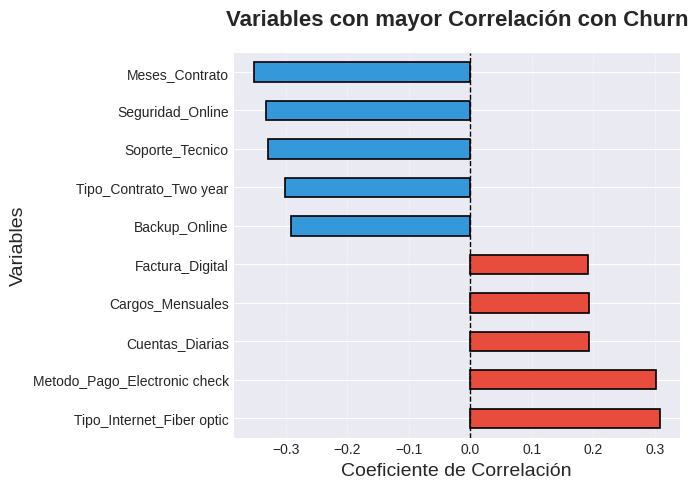


📈 Top 10 Correlaciones Positivas con Churn:
Tipo_Internet_Fiber optic                   0.308020
Metodo_Pago_Electronic check                0.301919
Cuentas_Diarias                             0.193412
Cargos_Mensuales                            0.193356
Factura_Digital                             0.191825
Adulto_Mayor                                0.150889
Multiples_Lineas_Sí                         0.040102
Servicio_Telefono                           0.011942
Genero                                     -0.008612
Multiples_Lineas_Sin servicio telefónico   -0.011942
Name: Evasion_Binaria, dtype: float64

📉 Top 10 Correlaciones Negativas con Churn:
Cargos_Totales               -0.198324
Streaming_TV                 -0.205742
Streaming_Peliculas          -0.207256
Tipo_Internet_Sin internet   -0.227890
Proteccion_Dispositivo       -0.281465
Backup_Online                -0.291449
Tipo_Contrato_Two year       -0.302253
Soporte_Tecnico              -0.329852
Seguridad_Online             -

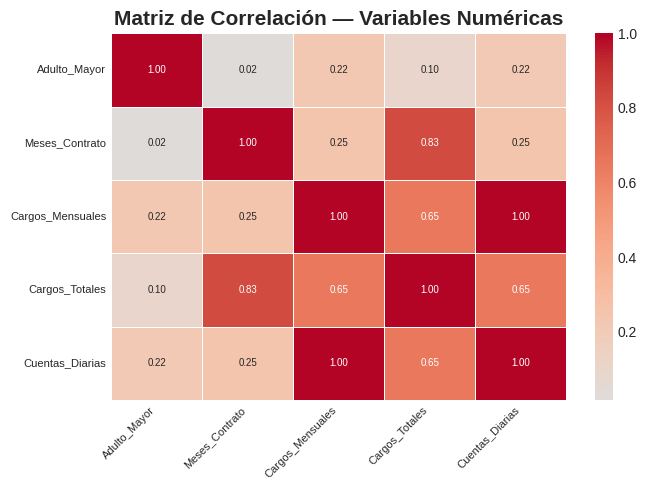

In [48]:
# Visualización de la matriz de correlación
# Seleccionar solo las correlaciones con Churn
churn_correlations = correlation_matrix['Evasion_Binaria'].sort_values(ascending=False)

# Excluir la correlación de Churn consigo mismo
churn_correlations = churn_correlations[churn_correlations.index != 'Evasion_Binaria']

# Top 10 variables más correlacionadas (positiva y negativamente)
top_n = 10
top_positive = churn_correlations.head(top_n//2)
top_negative = churn_correlations.tail(top_n//2)
top_correlations = pd.concat([top_positive, top_negative]).sort_values(ascending=False)

# Visualización
plt.figure(figsize=(7, 5))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_correlations.values]
top_correlations.plot(kind='barh', color=colors, edgecolor='black', linewidth=1.2)
plt.title('Variables con mayor Correlación con Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coeficiente de Correlación', fontsize=14)
plt.ylabel('Variables', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📈 Top 10 Correlaciones Positivas con Churn:")
print(churn_correlations.head(10))

print("\n📉 Top 10 Correlaciones Negativas con Churn:")
print(churn_correlations.tail(10))


# -------------------------------------------
# Correlación específica con Churn (ranking)
# -------------------------------------------
churn_corr = correlation_matrix['Evasion_Binaria'].drop('Evasion_Binaria')
churn_corr = churn_corr.sort_values(key=abs, ascending=False)

print("=== Correlación con Churn (ordenado por magnitud) ===\n")

for var, val in churn_corr.items():
    direccion = '🔴 positiva' if val > 0 else '🟢 negativa'
    print(f"{var:<45} {val:+.4f}  ({direccion})")

    # Matriz de correlación de variables numéricas normalizadas
corr_matrix = X_normalized[numericas].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Matriz de Correlación — Variables Numéricas', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

# Guardar imagen
plt.savefig('matriz_correlacion.png', dpi=150, bbox_inches='tight')

# Mostrar gráfico
plt.show()

### Detección de Multicolinealidad


In [49]:
# Detectar multicolinealidad
print("DETECCIÓN DE MULTICOLINEALIDAD")
print("="*40)

# Matriz de correlación absoluta (sin la variable target)
corr_matrix_features = X_normalized.corr().abs()

# Obtener la matriz triangular superior
upper_triangle = corr_matrix_features.where(
    np.triu(np.ones(corr_matrix_features.shape), k=1).astype(bool)
)

# Encontrar pares con correlación > 0.85
high_corr_pairs = []
for column in upper_triangle.columns:
    high_corr = upper_triangle[column][upper_triangle[column] > 0.85]
    for index in high_corr.index:
        high_corr_pairs.append((column, index, high_corr[index]))

if high_corr_pairs:
    print(f"\n⚠️ Se encontraron {len(high_corr_pairs)} pares con alta correlación (>0.85):")
    print("\n   Variable 1              Variable 2              Correlación")
    print("   " + "="*40)
    for var1, var2, corr in high_corr_pairs[:10]:  # Mostrar solo top 10
        print(f"   {var1:23} {var2:23} {corr:.3f}")

    if len(high_corr_pairs) > 10:
        print(f"   ... y {len(high_corr_pairs) - 10} pares más")



DETECCIÓN DE MULTICOLINEALIDAD

⚠️ Se encontraron 2 pares con alta correlación (>0.85):

   Variable 1              Variable 2              Correlación
   Cuentas_Diarias         Cargos_Mensuales        1.000
   Multiples_Lineas_Sin servicio telefónico Servicio_Telefono       1.000


## 🔍Entrenamiento y Testing

---

## Entrenamiento de Modelos de Clasificación

1. ** Regresión Logística**
2. ** Random Forest**
3. ** XGBoost**
---

In [68]:
#Lista de modelos a entrenar
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ===============================
# Lista de modelos a entrenar
# ===============================
modelos = {
    "Regresión Logística": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

# ===============================
# Entrenamiento y evaluación
# ===============================
for nombre, modelo in modelos.items():
    print(f"\n📊 ENTRENANDO {nombre.upper()}")
    print("="*60)

    # Entrenar
    modelo.fit(X_train, y_train)

    # Predicciones
    y_pred = modelo.predict(X_test)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print("\n✅ Modelo entrenado exitosamente")
    print("📈 Métricas de evaluación:")
    print(f"   • Accuracy : {acc:.4f}")
    print(f"   • Precision: {prec:.4f}")
    print(f"   • Recall   : {rec:.4f}")
    print(f"   • F1-Score : {f1:.4f}")
    print(f"   • ROC-AUC  : {roc_auc:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    print("\nMatriz de Confusión:")
    print(cm)


📊 ENTRENANDO REGRESIÓN LOGÍSTICA

✅ Modelo entrenado exitosamente
📈 Métricas de evaluación:
   • Accuracy : 0.7935
   • Precision: 0.6352
   • Recall   : 0.5214
   • F1-Score : 0.5727
   • ROC-AUC  : 0.8431

Matriz de Confusión:
[[923 112]
 [179 195]]

📊 ENTRENANDO RANDOM FOREST

✅ Modelo entrenado exitosamente
📈 Métricas de evaluación:
   • Accuracy : 0.7871
   • Precision: 0.6321
   • Recall   : 0.4733
   • F1-Score : 0.5413
   • ROC-AUC  : 0.8277

Matriz de Confusión:
[[932 103]
 [197 177]]

📊 ENTRENANDO XGBOOST

✅ Modelo entrenado exitosamente
📈 Métricas de evaluación:
   • Accuracy : 0.7814
   • Precision: 0.6122
   • Recall   : 0.4813
   • F1-Score : 0.5389
   • ROC-AUC  : 0.8414

Matriz de Confusión:
[[921 114]
 [194 180]]


---

## 📈 Evaluación y Comparación de Modelos

### Tabla Comparativa de Métricas

**Interpretación de Métricas:**

- **Accuracy:** % de predicciones correctas (puede engañar con datos desbalanceados)
- **Precision:** De los que predijimos como Churn, ¿cuántos realmente lo son?
- **Recall:** De todos los que hicieron Churn, ¿cuántos detectamos?
- **F1-Score:** Balance armónico entre Precision y Recall
- **ROC-AUC:** Capacidad del modelo para discriminar entre clases

In [83]:
metricas_modelos = []
probas_modelos = {}

for nombre, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    metricas_modelos.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    # guardar probabilidades para curvas ROC
    probas_modelos[nombre] = y_pred_proba


# ===============================
# Crear tabla comparativa
# ===============================

resultados = pd.DataFrame(metricas_modelos)

print("\n📊 COMPARACIÓN DE MODELOS")
print("="*80)
print(resultados.round(4).to_string(index=False))


📊 COMPARACIÓN DE MODELOS
             Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística    0.7935     0.6352  0.5214    0.5727   0.8431
      Random Forest    0.7871     0.6321  0.4733    0.5413   0.8277
            XGBoost    0.7814     0.6122  0.4813    0.5389   0.8414


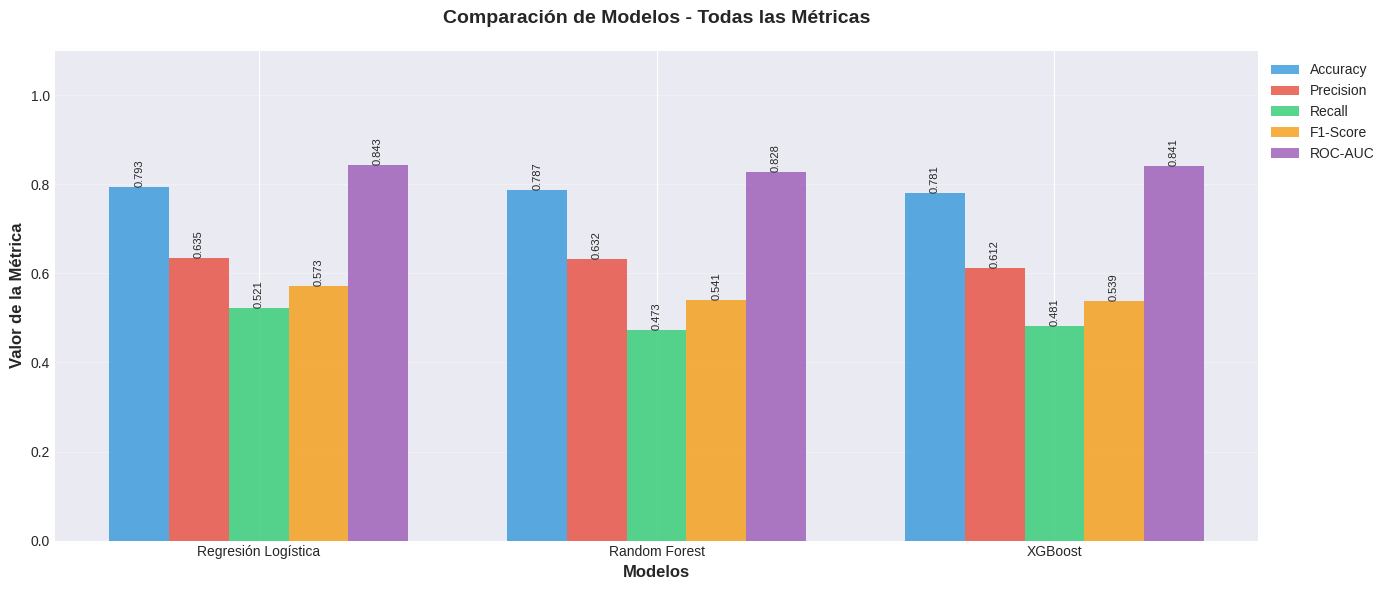

In [84]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(resultados))
width = 0.15

# Crear barras para cada métrica
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metrica, color) in enumerate(zip(metricas, colors)):
    offset = width * (i - 2)
    bars = ax.bar(x + offset, resultados[metrica], width, label=metrica, color=color, alpha=0.8)

    # Agregar valores sobre las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xlabel('Modelos', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor de la Métrica', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Modelos - Todas las Métricas', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(resultados['Modelo'])
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

### Curvas ROC (Receiver Operating Characteristic)


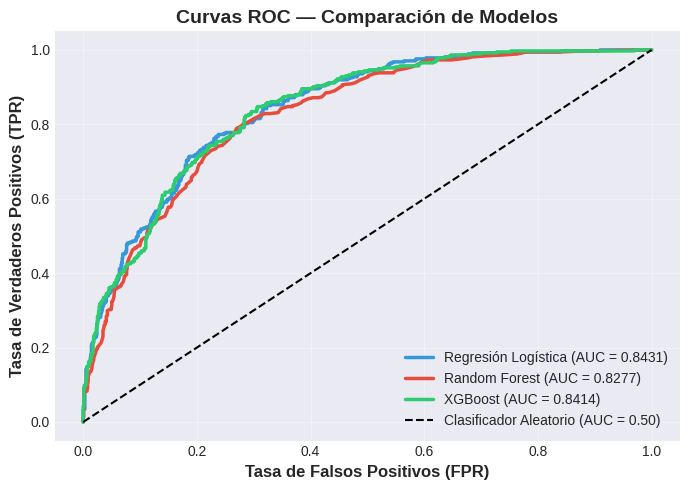


📊 Interpretación:
• Cuanto más cercana esté la curva a la esquina superior izquierda, mejor es el modelo.
• Un ROC-AUC > 0.80 generalmente indica un modelo con buen poder predictivo.


In [87]:
# ===============================
# Curvas ROC para los modelos
# ===============================

plt.figure(figsize=(7, 5))

# Colores para cada modelo
colores = {
    'Regresión Logística': '#3498db',
    'Random Forest': '#e74c3c',
    'XGBoost': '#2ecc71'
}

for modelo in probas_modelos:

    y_proba = probas_modelos[modelo]

    # obtener AUC desde la tabla de resultados
    auc = resultados.loc[resultados['Modelo'] == modelo, 'ROC-AUC'].values[0]

    # calcular curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.plot(
        fpr, tpr,
        label=f'{modelo} (AUC = {auc:.4f})',
        linewidth=2.5,
        color=colores[modelo]
    )

# Clasificador aleatorio
plt.plot([0, 1], [0, 1], 'k--',
         label='Clasificador Aleatorio (AUC = 0.50)',
         linewidth=1.5)

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12, fontweight='bold')
plt.title('Curvas ROC — Comparación de Modelos', fontsize=14, fontweight='bold')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("\n📊 Interpretación:")
print("• Cuanto más cercana esté la curva a la esquina superior izquierda, mejor es el modelo.")
print("• Un ROC-AUC > 0.80 generalmente indica un modelo con buen poder predictivo.")

---

## 🔬 Interpretación de Resultados

Interpretación de la comparación de modelos

**Dataset**:
7.043 clientes, 22 variables, sin valores nulos
Tasa de churn: 26.5% (1.869 clientes cancelaron)

Los tres modelos evaluados (Regresión Logística, Random Forest y XGBoost) presentan un desempeño relativamente similar, con valores cercanos en todas las métricas. Sin embargo, se observan algunas diferencias relevantes.

La Regresión Logística presenta el mejor desempeño global:

* Accuracy: 0.7935 (mayor entre los modelos)
* Precision: 0.6352 (ligeramente superior)
* Recall: 0.5214 (mayor capacidad de detectar clientes que abandonan)
* F1-Score: 0.5727 (mejor equilibrio entre precisión y recall)
ROC-AUC: 0.8431 (mayor capacidad de discriminación)
#
Esto indica que la Regresión Logística logra el mejor equilibrio entre identificar correctamente clientes que abandonan y evitar falsas predicciones.

Por otra parte, el modelo Random Forest presenta:
* Accuracy relativamente alto (0.7871)
* Buena precisión (0.6321)
* Menor recall (0.4733)

Esto sugiere que el modelo es más conservador, es decir, predice abandono con más cautela, pero pierde más casos reales de evasión.

El modelo XGBoost muestra un rendimiento similar al Random Forest:

* Accuracy: 0.7814
* Precision: 0.6122
* Recall: 0.4813
* ROC-AUC: 0.8414 (muy cercano al mejor modelo)

Aunque su capacidad de discriminación es alta (ROC-AUC elevado), su recall y F1-Score son ligeramente menores, lo que indica un desempeño algo inferior para identificar correctamente clientes que abandonan.

📈 Interpretación estratégica
---
Dado que el objetivo del análisis es predecir la evasión de clientes, el recall y el ROC-AUC son métricas especialmente importantes, ya que reflejan la capacidad del modelo para detectar clientes con riesgo de abandono.

Por ello:

* Regresión Logística identifica más clientes que abandonan
* Presenta mejor equilibrio entre precisión y sensibilidad
* Mantiene la mayor capacidad discriminativa (ROC-AUC)

🏆 Conclusión
---

En base a los resultados obtenidos, la Regresión Logística se posiciona como el modelo con mejor desempeño general, superando ligeramente a Random Forest y XGBoost en todas las métricas clave.

Por lo tanto, este modelo se considera el más adecuado para implementar un sistema de predicción de evasión de clientes, ya que ofrece el mejor equilibrio entre capacidad predictiva y detección efectiva de clientes con riesgo de abandono.

